# Welcome to lab_regression! <img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/items/poke-ball.png" width="35" style="vertical-align: middle; margin-bottom: 4px;"/>

One of the coolest parts of data science is **prediction** with **machine learning**. Up until now, we have done a myriad of data analysis given existing data. We have even generated our own data in simulations! Today, using some foundational concepts of machine learning, we will be making predictions based on data!

As you learned in lecture, **linear regression** is a powerful tool that can be used to quantify trends in data. We can use our Python skills to perform **simple linear regression** in this lab! 


A few tips to remember:

- **You are not alone on your journey in learning programming!** You have your lab TA, your CAs, your lab group, and the professors (Prof. Wade and Prof. Karle), who are all here to help you out!
- If you find yourself stuck for more than a few minutes, ask a neighbor or course staff for help! When you are giving help to your neighbor, explain the **idea and approach** to the problem without sharing the answer itself so they can have the same ***ah-hah*** moment!
- We are here to help you! Don't feel embarrassed or shy to ask us for help!

Let's get started!

In [459]:
# Meet your CAs and TA if you haven't already!
# ...first name is enough, we'll know who they are! :)
ta_name = "Jake"
ca1_name = "Soph"
ca2_name = "Maddy"
ca3_name = ""


# Say hello to each other!
# - Groups of 3 are ideal :)
# - However, groups of 2 or 4 are fine too!
#
# Question of the Day (QOTD) to Ask Your Group: "What was your favorite thing about DISCOVERY this semester?"
partner1_name = "Savanah"
partner1_netid = ""
partner1_DISCOVERYfave = "working with groups in lab"

partner2_name = "Esther"
partner2_netid = ""
partner2_DISCOVERYfave = ""

partner3_name = ""
partner3_netid = ""
partner3_DISCOVERYfave = ""


# Which lab section are you in? Record it below! It should start with a Y and have 
# 2 numbers after the Y. If you're unsure - ask your TA/CAs!
lab_section = "Y01"

## Part 1: Exploring the Pokemon Data
Today, we'll be working with a **Pokemon** dataset. For those unfamiliar, Pokemon are creatures that can be captured (caught) to fight alongside their trainers in the mythical Pokemon world featured in countless video games, cartoons, and cards. There are **tons** of Pokemon out there, so for the purposes of this lab, we will be dealing with pokemon from Generation One (Gen. One) to Generation Seven (Gen. Seven). Each Pokemon in the dataset is accompanied by its core attributes: Total Base Stat, Attack, Defense, HP, etc. 
 We will use basic **machine learning** techniques in this lab to **predict Total Base Stat** with a **linear regression** model. 

But before we approach this implementation of **simple linear regression**, let's **familiarize ourselves with the data** by doing some **EDA (Exploratory Data Analysis)**. This will include:
- Viewing a correlation matrix of our data
- Plotting visualizations to visually see relationships in the data

## Puzzle 1.1: Loading In the Data
We've provided you with a `pokemon.csv` file containing the Pokemon Dataset. You know the drill. Let's **import the Pokemon Dataset** in the cell below. Make sure you name your DataFrame `df`. 

In [460]:
import pandas as pd
df=pd.read_csv("pokemon.csv")
df

,Pokedex Number,Name,Primary Type,Secondary Type,Height (m),Weight (kg),Total Base Stat,Attack,Defense,HP,Speed,Special Attack,Special Defense,Legendary
0,1,Bulbasaur,grass,poison,0.7,6.9,318,49,49,45,45,65,65,0
1,2,Ivysaur,grass,poison,1.0,13.0,405,62,63,60,60,80,80,0
2,3,Venusaur,grass,poison,2.0,100.0,625,100,123,80,80,122,120,0
3,4,Charmander,fire,NaN,0.6,8.5,309,52,43,39,65,60,50,0
4,5,Charmeleon,fire,NaN,1.1,19.0,405,64,58,58,80,80,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,797,Celesteela,steel,flying,9.2,999.9,570,101,103,97,61,107,101,1
797,798,Kartana,grass,steel,0.3,0.1,570,181,131,59,109,59,31,1
798,799,Guzzlord,dark,dragon,5.5,888.0,570,101,53,223,43,97,53,1
799,800,Necrozma,psychic,NaN,2.4,230.0,600,107,101,97,79,127,89,1


In [461]:
## == TEST CASES for Puzzle 1.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors, check you previous cell, make changes, and RE-RUN your code and then this cell.
assert ( 'df' in vars() ), "Your DataFrame should be named df."
assert( len(df) == 801 ), "This is not the Pokemon Dataset we are looking for..."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 1.2: Narrowing Down our Dataset
You may have noticed that our `df` contains both **quantitative** (numeric) and **qualitative** (text-based) data. For this lab, we only want to consider **quantitative (numeric)** columns to predict **Total Base Stat**. Among the quantitative columns we only want to use the columns that capture **combat stats**. These are the columns titled **Total Base Stat, Attack, Defense, HP, Speed, Special Attack, and Special Defense**

Let's narrow down our dataset to only include the **quantitative (numeric) combat data**.

First, using the code cell below, define a **list** of **strings** called `numeric_cols` that contains all the columns in our `df` that capture **combat data**. 

In [462]:
numeric_cols = [ 'Total Base Stat', 'Attack', 'Defense', 'Speed', 'Special Defense', 'HP', 'Special Attack']

Next, we're going to create a new DataFrame called `df_numeric` that **only includes** the **combat columns**. Do this in the cell below.

In [463]:
df_numeric= df[numeric_cols]
df_numeric

,Total Base Stat,Attack,Defense,Speed,Special Defense,HP,Special Attack
0,318,49,49,45,65,45,65
1,405,62,63,60,80,60,80
2,625,100,123,80,120,80,122
3,309,52,43,65,50,39,60
4,405,64,58,80,65,58,80
...,...,...,...,...,...,...,...
796,570,101,103,61,101,97,107
797,570,181,131,109,31,59,59
798,570,101,53,43,53,223,97
799,600,107,101,79,89,97,127


In [464]:
## == TEST CASES for Puzzle 1.2  ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors,/ check you previous cell, make changes, and RE-RUN your code and then this cell.
import numpy as np 
assert( ('numeric_cols' in vars()) and (type(numeric_cols) == list)), "You should be creating a list of numeric columns named `numeric_cols`."
assert( len(numeric_cols) == 7 ), "There are exactly 7 numeric columns in this dataset."
assert( all(df[col].dtype in (np.float64, np.int64) for col in numeric_cols) ), "There is a non-numeric column in `numeric_cols`."

assert( 'df_numeric' in vars() ), "The new DataFrame should be named`df_numeric`."
assert( len(df) == len(df_numeric) ), "df_numeric should be the same length as our original df."
assert (len(df_numeric.columns.to_list()) == 7 ), "df_numeric should have 7 columns."
assert( all(df_numeric[col].dtype in (np.float64, np.int64) for col in df_numeric.columns) ), "There is a non-numeric column in df_numeric."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 1.3: Correlation Matrix
In lecture, you learned about the correlation coefficient $r$ which measures the **strength of linear association** between two variables ($x$ and $y$).

Find the correlation coefficient matrix for the numeric data.

In [465]:
df_numerical.corr()


,Total Base Stat,Attack,Defense,Speed,Special Defense,HP,Speed
Total Base Stat,1.000000,0.730134,0.629620,0.547666,0.717434,0.620624,0.547666
Attack,0.730134,1.000000,0.468915,0.352703,0.265836,0.410616,0.352703
Defense,0.629620,0.468915,1.000000,0.007934,0.526348,0.242378,0.007934
Speed,0.547666,0.352703,0.007934,1.000000,0.225977,0.160760,1.000000
Special Defense,0.717434,0.265836,0.526348,0.225977,1.000000,0.366971,0.225977
HP,0.620624,0.410616,0.242378,0.160760,0.366971,1.000000,0.160760
Speed,0.547666,0.352703,0.007934,1.000000,0.225977,0.160760,1.000000


### ML Vocabulary: Features and Labels

Quick vocabulary lesson! In machine learning, we often organize **instances** in our dataset into **features** and **labels** (in this lab, an **instance** is one row of our DataFrame). 

**Features** are characteristics that describe each **instance** in our dataset. These **features** are the **inputs** fed into machine learning models that will make **predictions**. They are our **independent variables**, or $X$. 

**Labels** are the output or **target** variables we are **trying to predict**. They are our **dependent variables**, or $y$. 

In the context of our Pokemon dataset, the single **label** we are trying to predict is the **Total Base Stat** of a pokemon. 

## Puzzle 1.4: Visualizations
For the purposes of this lab, we are ultimately interested in how we can best predict **Total Base Stat** with a **single feature** ($X$) from our DataFrame, `df`. 

But first, let's observe the relationships between various other columns in `df`. 

### Scatter Plot #1: Special Defense and Special Attack
Generate a scatter plot from `df` where the dependent variable ($y$) is `Special Defense` and independent variable ($X$) is `Special Attack`. Make sure to label the axes and have a title!

<Axes: title={'center': 'Relashionship Between Special Defense and Special Attack'}, xlabel='Special Attack', ylabel='Special Defense'>

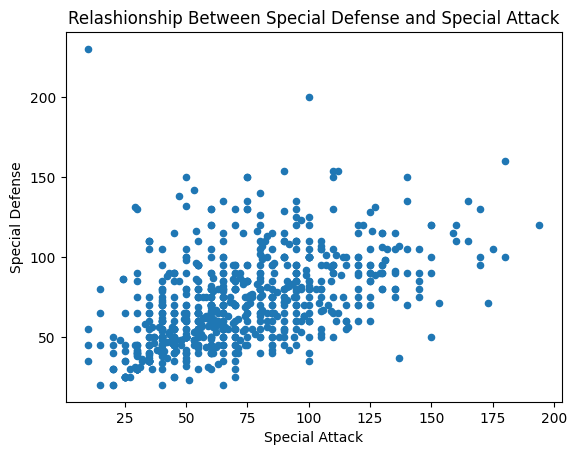

In [466]:
df.plot.scatter(x= "Special Attack", y= "Special Defense", title= "Relashionship Between Special Defense and Special Attack" )

### Scatter Plot #2: Speed and Defense
Generate a scatter plot from `df` where the dependent variable ($y$) is `Speed` and independent variable ($X$) is `Defense`. Make sure to label the axes and have a title!

<Axes: title={'center': 'Relashionship between Defense and Speed'}, xlabel='Defense', ylabel='Speed'>

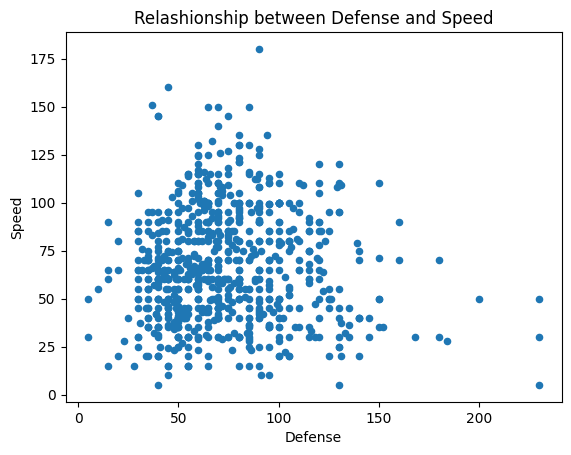

In [467]:
df.plot.scatter(x= "Defense", y= "Speed", title= "Relashionship between Defense and Speed" )

### Scatter Plot #3: Total Base Stat and Attack
Now, let's circle back to our original goal of predicting **Total Base Stat**. 

Generate a scatter plot from `df` where the dependent variable ($y$) is `Total Base Stat` and independent variable ($X$) is `Attack`. Make sure to label the axes and have a title!



<Axes: title={'center': 'Relasionship between Attack and Total Base Stat'}, xlabel='Attack', ylabel='Total Base Stat'>

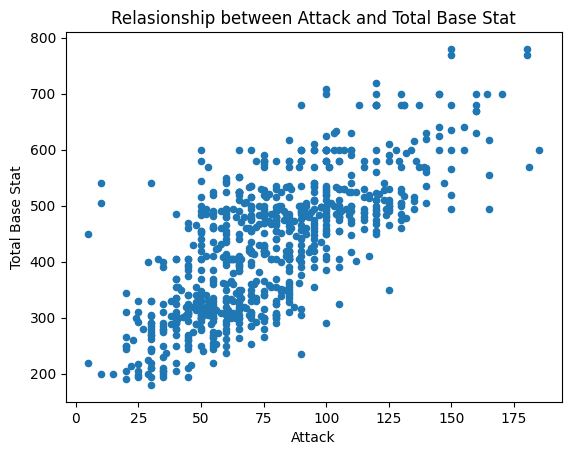

In [468]:
df.plot.scatter(x= "Attack", y= "Total Base Stat", title= "Relasionship between Attack and Total Base Stat")

<hr style="color: #DD3403;">

# Part 2: Simple Linear Regression

From Scatter Plot #3 above, you may have noticed that **Total Base Stat** and **Attack** have significant **linear correlation**. 

In lecture, we learned that **linear regression** allows us to predict values based on a "line of best fit". The equation for simple linear regression is:

> $$y = (\text{slope}) * X + \text{intercept}$$

For this portion of the lab, we will be using **linear regression** to explore the relationship between **Attack** and **Total Base Stat** of pokemon in our `df`. 

We can apply formulas we have learned in lecture alongside Python to create a **linear regression model** to predict **Total Base Stat** ($y$) given **Attack** ($X$).

## Puzzle 2.1: Calculating Slope of the Regression Line
In lecture, you learned how to **calculate the slope** of the regression line given your $X$ and $y$ columns of data. The formula is as follows:

> $$\text{slope} = r * \frac{SD(y)}{SD(x)}$$

Where $r$ is the correlation coefficient between $X$ and $y$, and $SD$ stands for standard deviation. 

In the cell below, find the correlation coefficient and store it in a variable called `r`. 

*(Note: The values shown in the displayed matrix in 1.3 are rounded, so make sure to use code to calculate the exact value for `r`.)*

**Tip**: Be sure to use `df_numeric` to calculate `r` since some versions of Pandas will not run a correlation matrix on a DataFrame that contains non-numeric data.

In [469]:
r = df_numeric.corr()["Total Base Stat"]["Attack"]
r.item()

0.7301341119500759

With this, find the slope of the regression line where the dependent variable ($y$) is `Total Base Stat` and the independent variable ($X$) is `Attack`, storing your answer in the **numeric variable** `slope` below:

In [470]:
slope= r *(df["Total Base Stat"].std() /df["Attack"].std())
slope.item()

2.7063989564936697

## Puzzle 2.2: Calculating Intercept of the Regression Line
You also learned how to calculate the **y-intercept** of the regression line in lecture. The formula is as follows:

> $$\text{intercept} = \text{avg}(y) - \text{slope} * \text{avg}(X)$$

Find the **y-intercept** of the regression line between `Total Base Stat` ($y$) and `Attack` ($X$), storing your result in the numeric variable `intercept` below: 

In [471]:
intercept= df["Total Base Stat"].mean()-slope * df["Attack"].mean()
intercept.item()

217.66309048343172

In [472]:
## == TEST CASES for Puzzle 2.1, 2.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors,/ check you previous cell, make changes, and RE-RUN your code and then this cell.
from math import isclose
assert( isclose(slope, 2.706398956493671, rel_tol=1e-6)), "The slope doesn't seem correct."
assert( isclose(intercept, 217.66309048343163, rel_tol=1e-6) ), "The intercept doesn't seem correct."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Visualizing Your Work: Seaborn 

If you **do not** have the `seaborn` library installed, try running any one of following commands in your **terminal** until successful installation:
- `python3 -m pip install seaborn`
- `pip install seaborn`
- `pip3 install seaborn`
- `py -m pip install seaborn`

If you are still having import errors trying these commands, **let your lab CAs and TAs know**! They will help you through the installation process. 

Now that you have calculated the **slope** and **y-intercept** of your regression line, let's **visualize** it. Run the following code that uses the `seaborn` library to **plot a regression line** on top of a scatter plot of between `Attack` and `Total Base Stat` - your regression line will be **red**. 

Text(0.5, 1.0, 'Attack vs Total Base Stat')

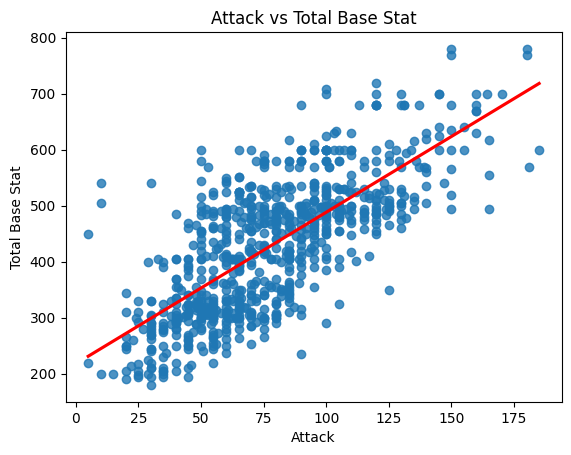

In [473]:
# Run the following code to see the regression line you made!!! :)
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot with regression line:
sns.regplot(data=df, x="Attack", y="Total Base Stat", ci=None, line_kws={'color':'red'})
plt.title("Attack vs Total Base Stat")

<hr style="color: #DD3403;">

# Part 3: Predictions and Residuals

## Puzzle 3.1: Predicting Total Base Stat

In Part 2, you found the intercept and slope for a line of best fit. Using your regression line, make a new column in our DataFrame `df` named `Total Base Stat Prediction`, which will store the **predicted Total Base Stat** for each Pokemon given its `Attack`. Use the values you calculated above in an equation of the regression line to populate this column. Remember,

> $$y = (\text{slope} * X) + \text{intercept}$$

In [474]:
df["Total Base Stat Prediction"]= (slope * df["Attack"]) + intercept
df

,Pokedex Number,Name,Primary Type,Secondary Type,Height (m),Weight (kg),Total Base Stat,Attack,Defense,HP,Speed,Special Attack,Special Defense,Legendary,Total Base Stat Prediction
0,1,Bulbasaur,grass,poison,0.7,6.9,318,49,49,45,45,65,65,0,350.276639
1,2,Ivysaur,grass,poison,1.0,13.0,405,62,63,60,60,80,80,0,385.459826
2,3,Venusaur,grass,poison,2.0,100.0,625,100,123,80,80,122,120,0,488.302986
3,4,Charmander,fire,NaN,0.6,8.5,309,52,43,39,65,60,50,0,358.395836
4,5,Charmeleon,fire,NaN,1.1,19.0,405,64,58,58,80,80,65,0,390.872624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,797,Celesteela,steel,flying,9.2,999.9,570,101,103,97,61,107,101,1,491.009385
797,798,Kartana,grass,steel,0.3,0.1,570,181,131,59,109,59,31,1,707.521302
798,799,Guzzlord,dark,dragon,5.5,888.0,570,101,53,223,43,97,53,1,491.009385
799,800,Necrozma,psychic,NaN,2.4,230.0,600,107,101,97,79,127,89,1,507.247779


In [475]:
## == TEST CASES for Puzzle 3.1  ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors,/ check you previous cell, make changes, and RE-RUN your code and then this cell.
from math import isclose
assert( 'Total Base Stat Prediction' in df.columns.to_list() ), "Your DataFrame df does not contain a new column `Total Base Stat Prediction`."
assert( isclose(df["Total Base Stat Prediction"].mean(), 428.37702871410744, rel_tol=1e-15) ), "You have not calculated the predicted Total Base Stat correctly. Double-check your formula."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 3.2: Calculating Residuals
Residuals are the **differences between** the **observed (actual) value** of $y$ (`Total Base Stat`) and the **predicted value** of $y$ (`Total Base Stat Prediction`, or just $\hat{y}$).

Let's **find the residuals** and **evaluate** the simple regression model! 

In the following cell, write the Python code create a new column called `Residual` to store the **residuals** or prediction errors.

In [476]:
df["Residual"]= df["Total Base Stat"] - df["Total Base Stat Prediction"]
df

,Pokedex Number,Name,Primary Type,Secondary Type,Height (m),Weight (kg),Total Base Stat,Attack,Defense,HP,Speed,Special Attack,Special Defense,Legendary,Total Base Stat Prediction,Residual
0,1,Bulbasaur,grass,poison,0.7,6.9,318,49,49,45,45,65,65,0,350.276639,-32.276639
1,2,Ivysaur,grass,poison,1.0,13.0,405,62,63,60,60,80,80,0,385.459826,19.540174
2,3,Venusaur,grass,poison,2.0,100.0,625,100,123,80,80,122,120,0,488.302986,136.697014
3,4,Charmander,fire,NaN,0.6,8.5,309,52,43,39,65,60,50,0,358.395836,-49.395836
4,5,Charmeleon,fire,NaN,1.1,19.0,405,64,58,58,80,80,65,0,390.872624,14.127376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,797,Celesteela,steel,flying,9.2,999.9,570,101,103,97,61,107,101,1,491.009385,78.990615
797,798,Kartana,grass,steel,0.3,0.1,570,181,131,59,109,59,31,1,707.521302,-137.521302
798,799,Guzzlord,dark,dragon,5.5,888.0,570,101,53,223,43,97,53,1,491.009385,78.990615
799,800,Necrozma,psychic,NaN,2.4,230.0,600,107,101,97,79,127,89,1,507.247779,92.752221


Now, let's try to find the top **20 pokemon** with the highest residual in absolute value and store it in a DataFrame `df_worst_predictions`.<br>
**Hint**: You will need to create a new column named `Absolute Residual` using the `abs()` function (look back to `lab_justice` part 2.4).


In [477]:
df["Residual"] = df["Total Base Stat"] - df["Total Base Stat Prediction"]
df["Absolute Residual"] = abs(df["Residual"])
df_worst_predictions = df.sort_values("Absolute Residual", ascending=False).head(20)
df_worst_predictions

,Pokedex Number,Name,Primary Type,Secondary Type,Height (m),Weight (kg),Total Base Stat,Attack,Defense,HP,Speed,Special Attack,Special Defense,Legendary,Total Base Stat Prediction,Residual,Absolute Residual
241,242,Blissey,normal,NaN,1.5,46.8,540,10,10,255,55,75,135,0,244.727080,295.272920,295.272920
212,213,Shuckle,bug,rock,0.6,20.5,505,10,230,20,5,10,230,0,244.727080,260.272920,260.272920
64,65,Alakazam,psychic,NaN,1.5,48.0,600,50,65,55,150,175,105,0,352.983038,247.016962,247.016962
554,555,Darmanitan,fire,fire,1.3,92.9,540,30,105,105,55,140,105,0,298.855059,241.144941,241.144941
377,378,Regice,ice,NaN,1.8,175.0,580,50,100,80,50,100,200,1,352.983038,227.016962,227.016962
291,292,Shedinja,bug,ghost,0.8,1.2,236,90,45,1,40,30,30,0,461.238997,-225.238997,225.238997
717,718,Zygarde,dragon,ground,5.0,284.6,708,100,121,216,85,91,95,1,488.302986,219.697014,219.697014
112,113,Chansey,normal,NaN,1.1,34.6,450,5,5,250,50,35,105,0,231.195085,218.804915,218.804915
248,249,Lugia,psychic,flying,5.2,216.0,680,90,130,106,110,90,154,1,461.238997,218.761003,218.761003
379,380,Latias,dragon,psychic,1.4,40.0,700,100,120,80,110,140,150,1,488.302986,211.697014,211.697014


In [478]:
## == TEST CASES for Puzzle 3.2  ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors,/ check you previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert(abs(df['Residual'].sum()) < 0.0001), "The residuals might not be correct. Please check again!"
assert( 'Absolute Residual' in df.columns.to_list() ), "Your DataFrame df does not contain a new column `Absolute Residual`."
assert( 'df_worst_predictions' in vars() ), "You should be creating a DataFrame named `df_worst_predictions`."
assert( len(df_worst_predictions) == 20 ), "There should be 20 rows in df_worst_predictions."
assert(isclose(df_worst_predictions['Absolute Residual'].mean(), 213.2032132585081, rel_tol=1e-7) ), "You have not populated the Absolute Residual column correctly."


## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 3.3: Legendary Pokemon
What percentage of the 20 pokemon in `df_worst_predictions` are legendary pokemon? Legendary Pokemon are ultra-rare, high-powered Pokemon. These pokemon have a value of 1 in the `Legendary` column of our DataFrame. Store the result in a variable named `percentage_legendary_worst`.

In [482]:
num_legendary= df_worst_predictions["Legendary"].sum()
percentage_legendary_worst= (num_legendary/ len (df_worst_predictions))
percentage_legendary_worst.item()

0.35

In [480]:
## == TEST CASES for Puzzle 3.3  ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors,/ check you previous cell, make changes, and RE-RUN your code and then this cell.
assert(isclose(percentage_legendary_worst, round(np.pi * 0.1115, 2) )), "The percentage of Legendary Pokemon in the worst 20 residuals is not correct. Check your code."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Analysis Questions

**Question 1**: Looking at the plots from Puzzle 1.4, describe the correlation between each pair of variables. Is the relationship positive or negative? Does it seem linear or non-linear? Is there a strong or weak *relationship* between the variables? Do this for all 3 plots.

**Question 2**: Looking at Puzzle 2.1 and Puzzle 2.2, how do you interpret your slope and y-intercept? Make sure to interpret these in the context of the problem!

**Question 3**: Looking at Puzzle 3.3, does our model appear to perform worse on legendary or non-legendary pokemon? Think about what other information we need to answer this question. Use the code cell below the markdown cell to obtain this information and answer the question.

1. It seems like when you examine the relationship between the variables of Special Attack and Special Defense on the Scatterplot, it does appear to have a moderate positive correlation. In other words, as a Pokémon's Special Attack increases, we can expect their Special Defense will tend to be greater. The points on the graph appear to follow a trend that is generally upward sloping, yet there is considerable scatter about this line. This is a reasonable conclusion since many of the Pokémon that possess powerful offensive special abilities are likely to have some degree of defensive capability. However, it is not a perfect relationship.

On the other hand, when looking at the relationship of Attack and Total Base Stats from the scatterplot, we see a very strong positive linear relationship. As the Attack value of a Pokémon increases, so does the Total Base Stat for the same Pokémon. The correlation coefficient (𝒓) ≈ .73 r≈.73 is a significant enough positive correlation to indicate that the Attack ability is a very good predictor of a Pokémon's total strength. That is to say, if a Pokémon has a very high Attack, they will also typically have a very high overall base stat.

In contrast, the relationship between Defense and Speed in the scatterplot is a weak negative relationship. There doesn't seem to be any clear linear relationship present in the data; however, as a general rule, Pokémon with higher Defense tend to have lower Speed. This is a logical assumption, as heavy armor or defensive types of Pokémon tend to be slow, whereas faster Pokémon tend to sacrifice defensive capability. Generally speaking, this is a weak, non-linear relationship when comparing it to the relationships demonstrated in the previous two scatterplots.

2. Using the results from my regression equation I determined the slope of the model to be around 2.706. The slope indicates the number of point changes in Total Base Stat (on average) as a result of a single point increase in Attack. Therefore, there appears to be a strong positive relationship between Attack and total base stats, meaning that higher Attack values are typically associated with higher overall base stats. Thus, this indicates that the attack value contributes significantly to the overall strength of the Pokémon.

The y-intercept is approximately 4.0, which is the Total Base Stat that the model will predict if the Attack value is zero. Since it is impossible for a Pokémon's Attack stat to be zero, the y-intercept does not represent anything meaningful in reality. It is simply an arbitrary point that the regression line uses to determine how best to fit the model to the data. Although the y-intercept does not provide a significant interpretation, the slope provides a clear representation of the positive relationship between the two variables of interest.

3. The 35 % (or .35) of Pokémon with the highest Absolute Residuals (from the 20 total Pokémon with the highest Absolute Residuals) that were Legendary (as shown by Puzzle 3.3), indicates that the model is worse at estimating stats for Legendary Pokémon than for non-Legendary Pokémon. The stats for most Pokémon are fairly evenly distributed; however, Legendary Pokémon often have extremely high or out-of-balance stats which do not follow a linear pattern similar to that of other Pokémon. Only about 5 – 10 % of Pokémon in the data base were Legendary, it would be very clear that the model was having trouble to estimate Legendary Pokémon stats, since they made up 35% of the worst predictions. Thus, the regression model fits the stats of non-Legendary Pokémon much better than those of Legendary Pokémon, and therefore produces much larger errors when trying to estimate stats of Legendary Pokémon, because the special attributes of Legendary Pokémon fall outside the trends of the model.

In [484]:
# Use this code cell to help answer Q3
overall_legendary_percentage= df["Legendary"].mean()
overall_legendary_percentage.item()

0.08739076154806492

<hr style="color: #DD3403;">

# Submission

You're almost done!  All you need to do is to commit your lab to GitHub:

1.  ⚠️ **Make certain to save your work.** ⚠️ To do this, go to **File => Save All**

2.  After you have saved, exit this notebook and follow the Canvas instructions to commit this lab to your Git repository!

3. Your TA will grade your submission and provide you feedback after the lab is due. :)